In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import os

# Load VNQ data
df_vnq = pd.read_csv("VNQ.csv")

# Convert Date
df_vnq["Date"] = pd.to_datetime(df_vnq["Date"])

# Sort by date
df_vnq = df_vnq.sort_values("Date").reset_index(drop=True)

print("VNQ data loaded successfully.")
print("Shape:", df_vnq.shape)

display(df_vnq.head())

VNQ data loaded successfully.
Shape: (3774, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-01-04,45.220001,45.419998,44.200001,44.549999,23.346331,2408400
1,2010-01-05,44.500000,44.580002,43.930000,44.500000,23.320124,2054200
2,2010-01-06,44.520000,44.840000,44.299999,44.419998,23.278194,2471200
3,2010-01-07,44.459999,45.099998,43.950001,44.900002,23.529734,2091700
4,2010-01-08,44.810001,44.849998,44.180000,44.570000,23.356806,2682000


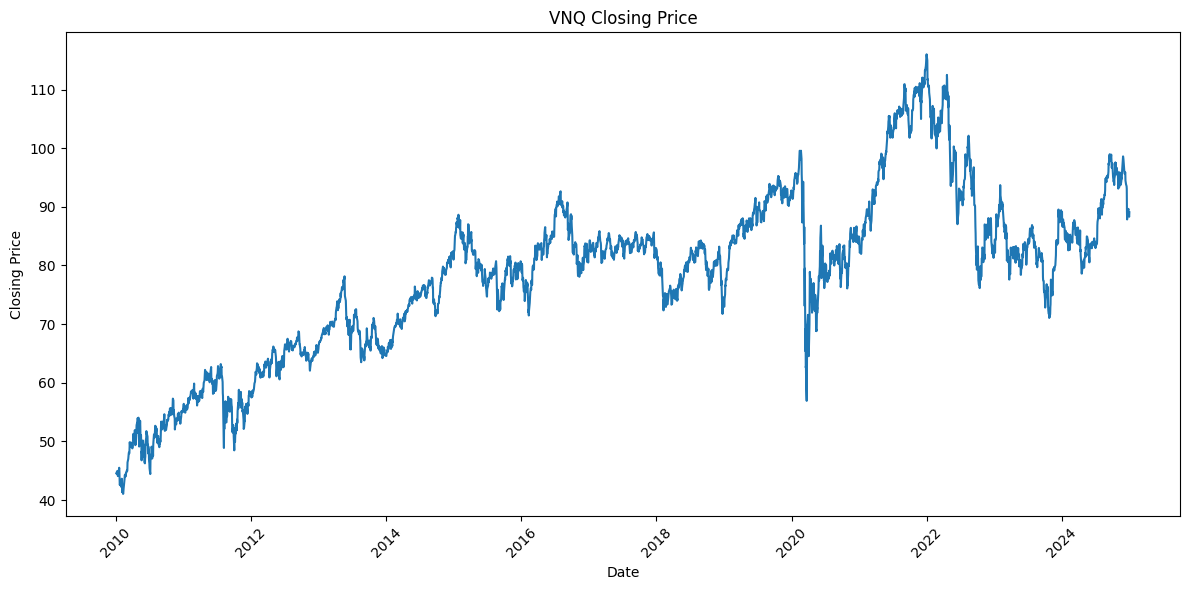

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
plt.figure(figsize=(12, 6))

plt.plot(df_vnq["Date"], df_vnq["Close"])

plt.title("VNQ Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)

plt.tight_layout()

file_path = "VNQ_Closing_Price.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

files.download(file_path)

In [3]:
df_vnq["Daily_Return"] = df_vnq["Close"].pct_change()

df_vnq = df_vnq.dropna(
    subset=["Daily_Return"]
).reset_index(drop=True)

print("Daily Return created successfully.")

display(
    df_vnq[["Date", "Close", "Daily_Return"]].head(10)
)

Daily Return created successfully.


,Date,Close,Daily_Return
0,2010-01-05,44.500000,-0.001122
1,2010-01-06,44.419998,-0.001798
2,2010-01-07,44.900002,0.010806
3,2010-01-08,44.570000,-0.007350
4,2010-01-11,44.830002,0.005834
5,2010-01-12,44.080002,-0.016730
6,2010-01-13,44.970001,0.020191
7,2010-01-14,44.930000,-0.000890
8,2010-01-15,44.590000,-0.007567
9,2010-01-19,45.500000,0.020408


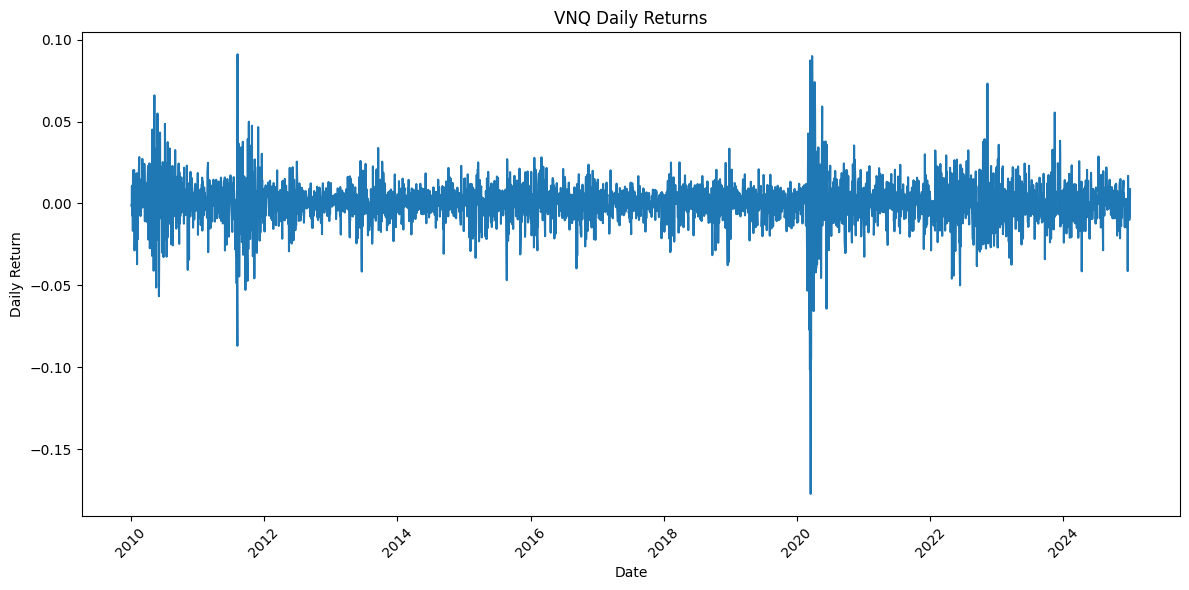

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
plt.figure(figsize=(12, 6))

plt.plot(
    df_vnq["Date"],
    df_vnq["Daily_Return"]
)

plt.title("VNQ Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.xticks(rotation=45)

plt.tight_layout()

file_path = "VNQ_Daily_Returns.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

files.download(file_path)

VNQ data loaded successfully.
Original shape: (3774, 7)


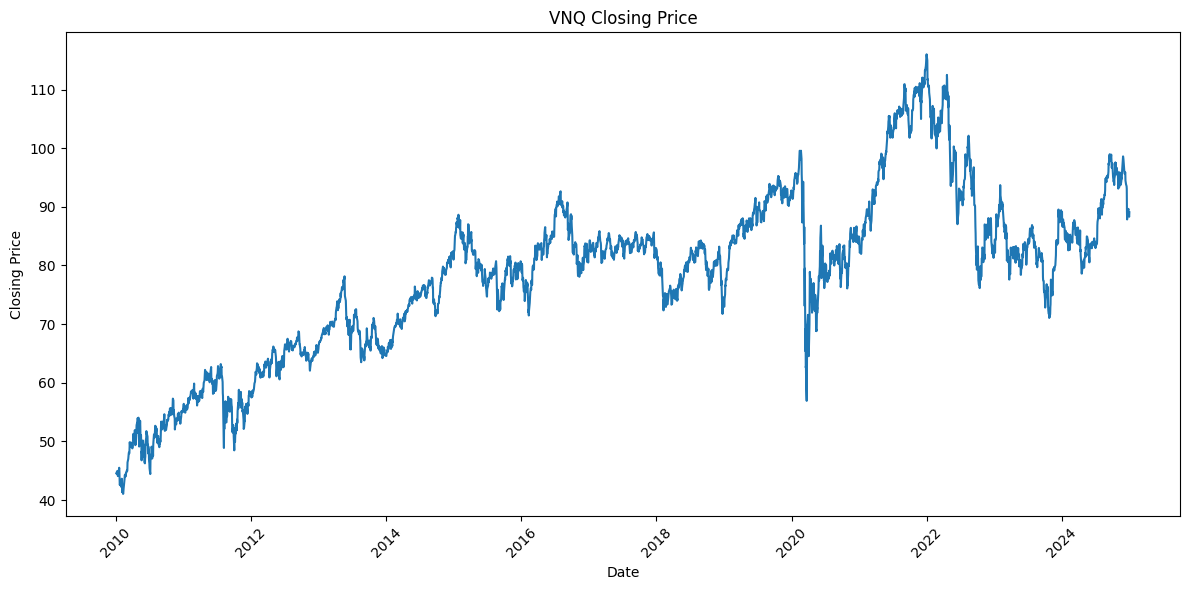

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

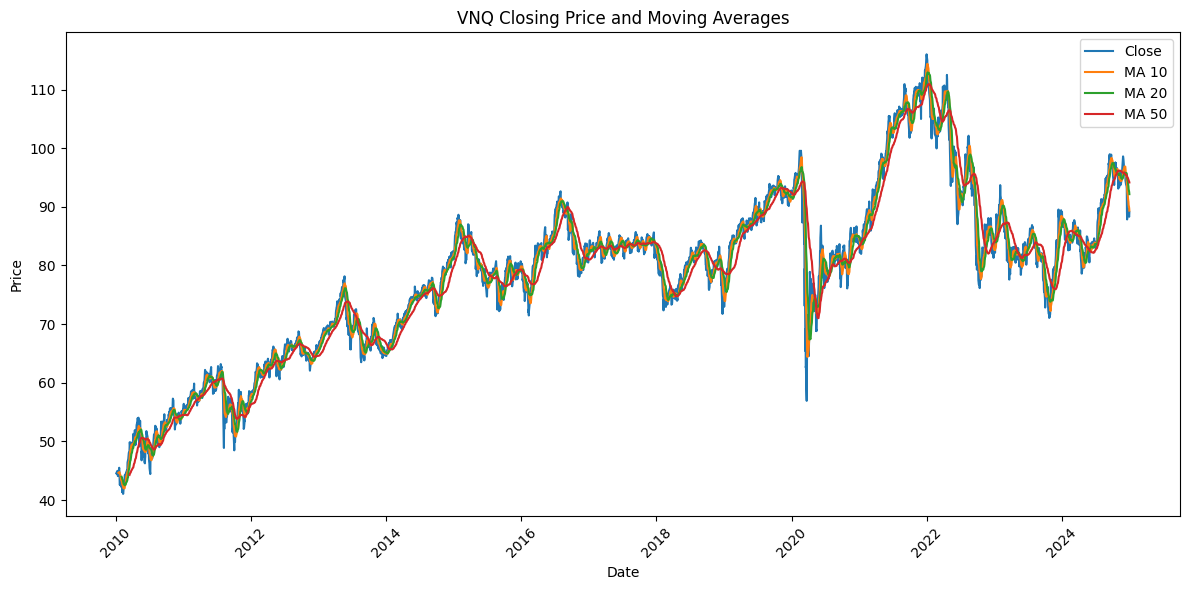

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

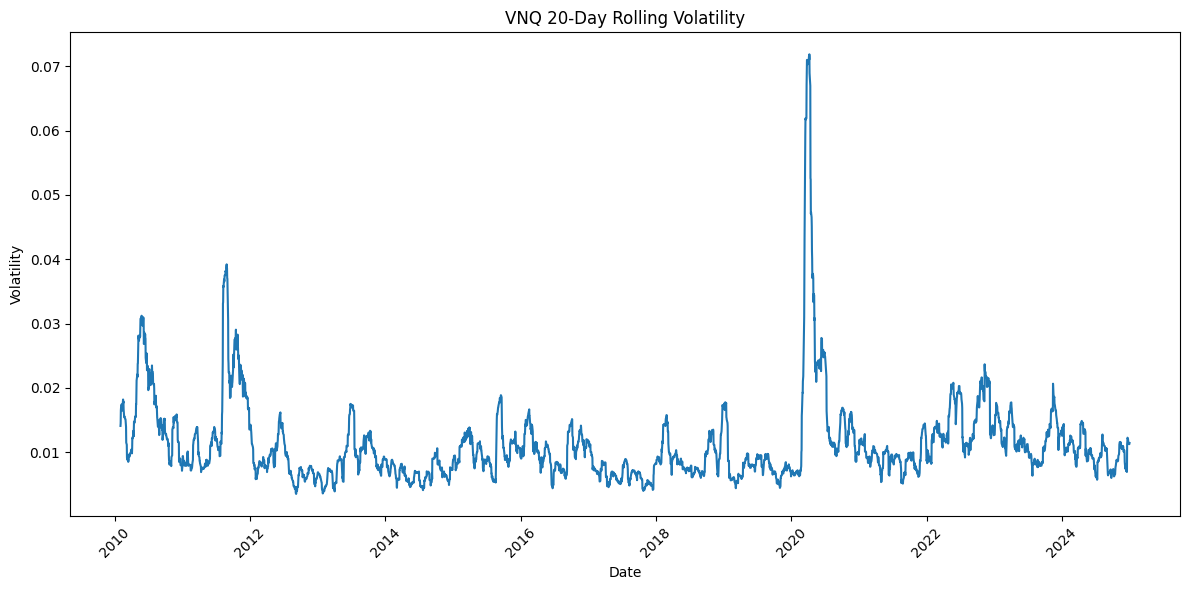

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

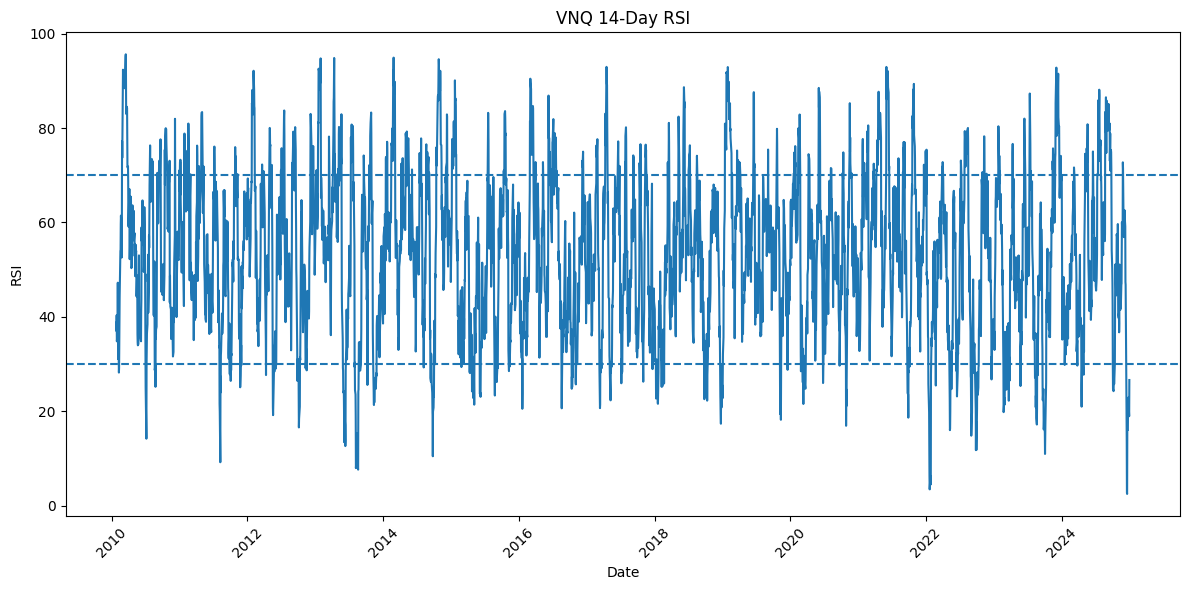

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

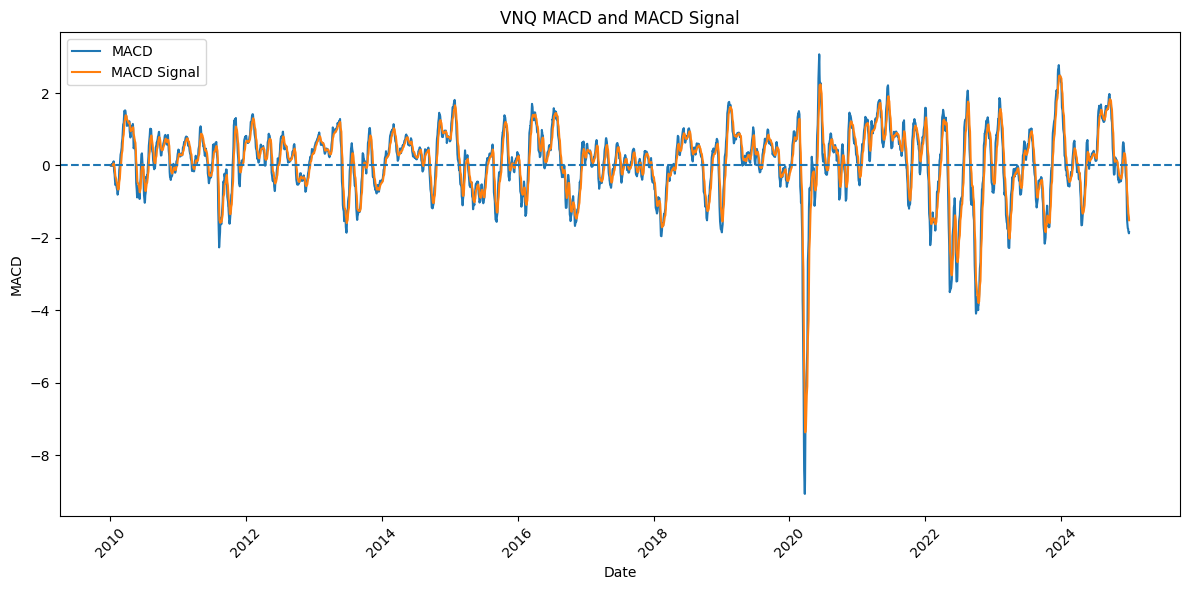

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

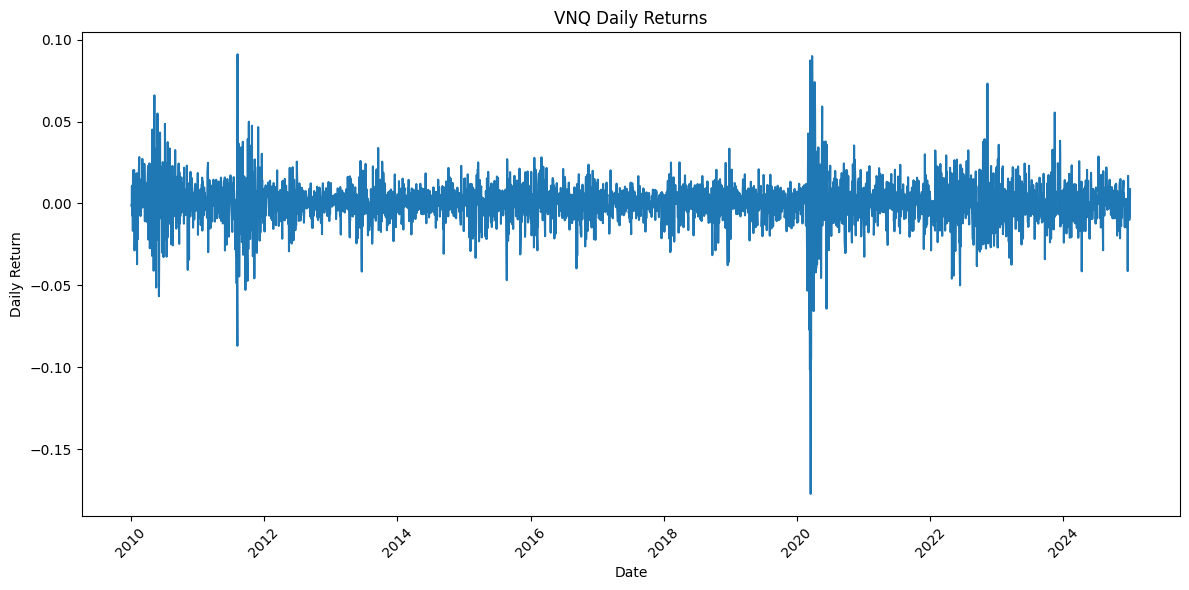

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Processed VNQ shape:
(3725, 15)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Training samples: 2979
Testing samples: 745

VNQ model training completed successfully.
VNQ prediction completed successfully.


VNQ MODEL EVALUATION RESULTS
MAE  : 0.8836
MSE  : 1.3749
RMSE : 1.1726
R²   : 0.9812


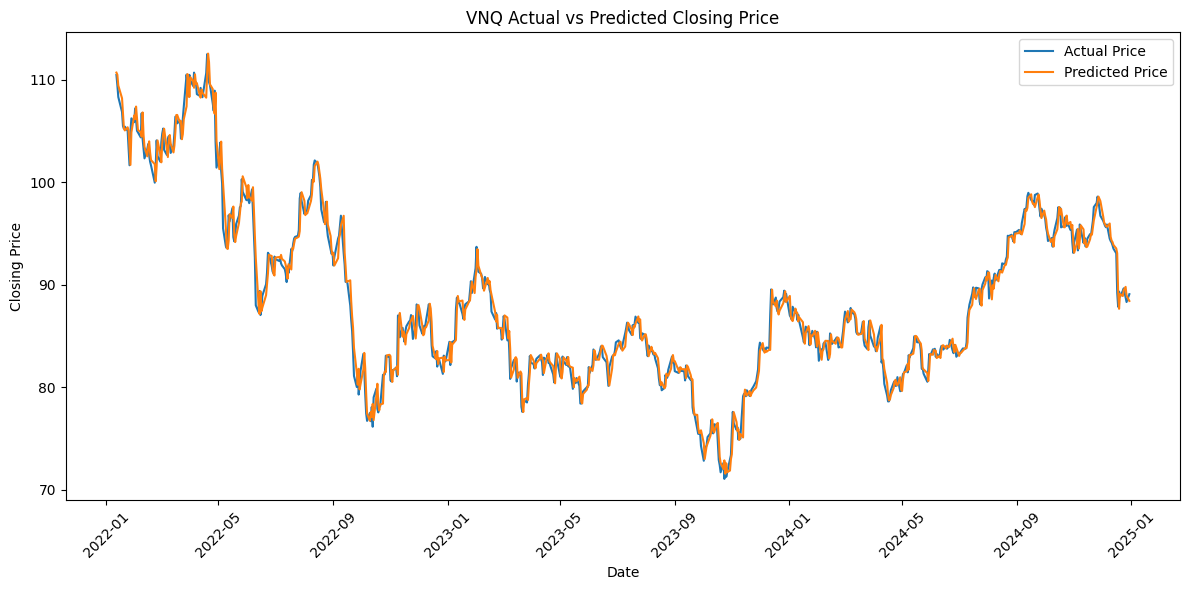

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


VNQ WORKFLOW COMPLETED SUCCESSFULLY.

Files created:
1. VNQ_Closing_Price.png
2. VNQ_Daily_Returns.png
3. VNQ_Moving_Averages.png
4. VNQ_Volatility_20.png
5. VNQ_RSI_14.png
6. VNQ_MACD.png
7. VNQ_features.csv
8. VNQ_Actual_vs_Predicted.png
9. VNQ_Evaluation_Metrics.csv
10. VNQ_Prediction_Results.csv


In [5]:
# ============================================================
# VNQ COMPLETE DATA SCIENCE WORKFLOW
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

df_vnq = pd.read_csv("VNQ.csv")

df_vnq["Date"] = pd.to_datetime(df_vnq["Date"])

df_vnq = (
    df_vnq
    .sort_values("Date")
    .drop_duplicates(subset=["Date"])
    .reset_index(drop=True)
)

print("VNQ data loaded successfully.")
print("Original shape:", df_vnq.shape)


# ------------------------------------------------------------
# 2. DAILY RETURN
# ------------------------------------------------------------

df_vnq["Daily_Return"] = df_vnq["Close"].pct_change()


# ------------------------------------------------------------
# 3. MOVING AVERAGES
# ------------------------------------------------------------

df_vnq["MA_10"] = df_vnq["Close"].rolling(10).mean()
df_vnq["MA_20"] = df_vnq["Close"].rolling(20).mean()
df_vnq["MA_50"] = df_vnq["Close"].rolling(50).mean()


# ------------------------------------------------------------
# 4. VOLATILITY
# ------------------------------------------------------------

df_vnq["Volatility_20"] = (
    df_vnq["Daily_Return"].rolling(20).std()
)


# ------------------------------------------------------------
# 5. RSI
# ------------------------------------------------------------

delta = df_vnq["Close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

df_vnq["RSI_14"] = 100 - (100 / (1 + rs))


# ------------------------------------------------------------
# 6. MACD
# ------------------------------------------------------------

ema_12 = df_vnq["Close"].ewm(
    span=12,
    adjust=False
).mean()

ema_26 = df_vnq["Close"].ewm(
    span=26,
    adjust=False
).mean()

df_vnq["MACD"] = ema_12 - ema_26

df_vnq["MACD_Signal"] = (
    df_vnq["MACD"]
    .ewm(span=9, adjust=False)
    .mean()
)


# ------------------------------------------------------------
# 7. SAVE FIGURES
# ------------------------------------------------------------

# Closing Price
plt.figure(figsize=(12, 6))
plt.plot(df_vnq["Date"], df_vnq["Close"])
plt.title("VNQ Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.tight_layout()

file_path = "VNQ_Closing_Price.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()
files.download(file_path)


# Moving Averages
plt.figure(figsize=(12, 6))
plt.plot(df_vnq["Date"], df_vnq["Close"], label="Close")
plt.plot(df_vnq["Date"], df_vnq["MA_10"], label="MA 10")
plt.plot(df_vnq["Date"], df_vnq["MA_20"], label="MA 20")
plt.plot(df_vnq["Date"], df_vnq["MA_50"], label="MA 50")
plt.title("VNQ Closing Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

file_path = "VNQ_Moving_Averages.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()
files.download(file_path)


# Volatility
plt.figure(figsize=(12, 6))
plt.plot(
    df_vnq["Date"],
    df_vnq["Volatility_20"]
)
plt.title("VNQ 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.xticks(rotation=45)
plt.tight_layout()

file_path = "VNQ_Volatility_20.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()
files.download(file_path)


# RSI
plt.figure(figsize=(12, 6))
plt.plot(
    df_vnq["Date"],
    df_vnq["RSI_14"]
)
plt.axhline(70, linestyle="--")
plt.axhline(30, linestyle="--")
plt.title("VNQ 14-Day RSI")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.xticks(rotation=45)
plt.tight_layout()

file_path = "VNQ_RSI_14.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()
files.download(file_path)


# MACD
plt.figure(figsize=(12, 6))
plt.plot(
    df_vnq["Date"],
    df_vnq["MACD"],
    label="MACD"
)
plt.plot(
    df_vnq["Date"],
    df_vnq["MACD_Signal"],
    label="MACD Signal"
)
plt.axhline(0, linestyle="--")
plt.title("VNQ MACD and MACD Signal")
plt.xlabel("Date")
plt.ylabel("MACD")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

file_path = "VNQ_MACD.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()
files.download(file_path)


# Daily Returns
plt.figure(figsize=(12, 6))
plt.plot(
    df_vnq["Date"],
    df_vnq["Daily_Return"]
)
plt.title("VNQ Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.xticks(rotation=45)
plt.tight_layout()

file_path = "VNQ_Daily_Returns.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()
files.download(file_path)


# ------------------------------------------------------------
# 8. CREATE PROCESSED DATASET
# ------------------------------------------------------------

feature_columns = [
    "Date",
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close",
    "Volume",
    "Daily_Return",
    "MA_10",
    "MA_20",
    "MA_50",
    "Volatility_20",
    "RSI_14",
    "MACD",
    "MACD_Signal"
]

df_vnq_features = (
    df_vnq[feature_columns]
    .dropna()
    .reset_index(drop=True)
)

print("\nProcessed VNQ shape:")
print(df_vnq_features.shape)


# Save processed dataset
df_vnq_features.to_csv(
    "VNQ_features.csv",
    index=False
)

files.download("VNQ_features.csv")


# ------------------------------------------------------------
# 9. CREATE TARGET
# ------------------------------------------------------------

df_ml_vnq = df_vnq_features.copy()

df_ml_vnq["Target"] = (
    df_ml_vnq["Close"].shift(-1)
)

df_ml_vnq = (
    df_ml_vnq
    .dropna()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 10. SELECT FEATURES
# ------------------------------------------------------------

model_features = [
    "Close",
    "Daily_Return",
    "MA_10",
    "MA_20",
    "MA_50",
    "Volatility_20",
    "RSI_14",
    "MACD",
    "MACD_Signal"
]

X = df_ml_vnq[model_features]
y = df_ml_vnq["Target"]


# ------------------------------------------------------------
# 11. TIME-SERIES TRAIN/TEST SPLIT
# ------------------------------------------------------------

split_index = int(len(df_ml_vnq) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ------------------------------------------------------------
# 12. SCALE FEATURES
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# ------------------------------------------------------------
# 13. TRAIN MODEL
# ------------------------------------------------------------

model_vnq = LinearRegression()

model_vnq.fit(
    X_train_scaled,
    y_train
)

print("\nVNQ model training completed successfully.")


# ------------------------------------------------------------
# 14. PREDICTION
# ------------------------------------------------------------

y_pred_vnq = model_vnq.predict(
    X_test_scaled
)

print("VNQ prediction completed successfully.")


# ------------------------------------------------------------
# 15. EVALUATION
# ------------------------------------------------------------

actual_vnq = np.array(y_test)
predicted_vnq = np.array(y_pred_vnq)

mae_vnq = mean_absolute_error(
    actual_vnq,
    predicted_vnq
)

mse_vnq = mean_squared_error(
    actual_vnq,
    predicted_vnq
)

rmse_vnq = np.sqrt(mse_vnq)

r2_vnq = r2_score(
    actual_vnq,
    predicted_vnq
)

print("\n")
print("=" * 50)
print("VNQ MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"MAE  : {mae_vnq:.4f}")
print(f"MSE  : {mse_vnq:.4f}")
print(f"RMSE : {rmse_vnq:.4f}")
print(f"R²   : {r2_vnq:.4f}")
print("=" * 50)


# ------------------------------------------------------------
# 16. ACTUAL VS PREDICTED FIGURE
# ------------------------------------------------------------

test_dates_vnq = (
    df_ml_vnq["Date"]
    .iloc[split_index:]
    .reset_index(drop=True)
)

plt.figure(figsize=(12, 6))

plt.plot(
    test_dates_vnq,
    actual_vnq,
    label="Actual Price"
)

plt.plot(
    test_dates_vnq,
    predicted_vnq,
    label="Predicted Price"
)

plt.title("VNQ Actual vs Predicted Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

file_path = "VNQ_Actual_vs_Predicted.png"

plt.savefig(
    file_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

files.download(file_path)


# ------------------------------------------------------------
# 17. SAVE EVALUATION RESULTS
# ------------------------------------------------------------

evaluation_vnq = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R2"
    ],
    "Value": [
        mae_vnq,
        mse_vnq,
        rmse_vnq,
        r2_vnq
    ]
})

evaluation_vnq.to_csv(
    "VNQ_Evaluation_Metrics.csv",
    index=False
)

files.download(
    "VNQ_Evaluation_Metrics.csv"
)


# ------------------------------------------------------------
# 18. SAVE PREDICTION RESULTS
# ------------------------------------------------------------

prediction_vnq = pd.DataFrame({
    "Date": test_dates_vnq,
    "Actual": actual_vnq,
    "Predicted": predicted_vnq
})

prediction_vnq["Error"] = (
    prediction_vnq["Actual"] -
    prediction_vnq["Predicted"]
)

prediction_vnq.to_csv(
    "VNQ_Prediction_Results.csv",
    index=False
)

files.download(
    "VNQ_Prediction_Results.csv"
)


# ------------------------------------------------------------
# 19. FINAL CHECK
# ------------------------------------------------------------

print("\nVNQ WORKFLOW COMPLETED SUCCESSFULLY.")

print("\nFiles created:")
print("1. VNQ_Closing_Price.png")
print("2. VNQ_Daily_Returns.png")
print("3. VNQ_Moving_Averages.png")
print("4. VNQ_Volatility_20.png")
print("5. VNQ_RSI_14.png")
print("6. VNQ_MACD.png")
print("7. VNQ_features.csv")
print("8. VNQ_Actual_vs_Predicted.png")
print("9. VNQ_Evaluation_Metrics.csv")
print("10. VNQ_Prediction_Results.csv")